In [3]:
from numpy.fft import fft, ifft, fftshift
from matplotlib.pyplot import *
import matplotlib.patheffects as pe
import matplotlib as mtpltlb
from scipy import signal
import scipy.ndimage as ndi
import scipy.interpolate as interp
import os
import numpy as np

np.seterr(divide='warn', invalid='warn')

# import seaborn for pretty plots
import seaborn as sns
sns.set_style('ticks')
sns.set_context('notebook')

# Create a modified Jet colormap with white as zero
jet = cm.get_cmap('jet', 20)
r = []
g = []
b = []
npoints = 10
for ii in range(0, npoints):
    val = ii / (npoints - 1.0)
    color = jet(val)
    r.append(color[0])
    g.append(color[1])
    b.append(color[2])
r[0] = 1.0
g[0] = 1.0
b[0] = 1.0

ll = [(r[ii], g[ii], b[ii]) for ii in range(0, len(r))]
modified_jet = mtpltlb.colors.LinearSegmentedColormap.from_list('2D_colormap', ll)



In [5]:
def time2freq(t,Nbw):
    """
    Parameters
    ----------
    t : array of floats
        time
    Nbw : integer
        Nunmber of points to be used. Nbw must be greater that Nbt=len(t) for ZERO-PADDING
    
    Returns
    -------
    w : angular frequency

    """
    # temporal sampling rate
    delta_t=t[1]-t[0] 
    # total temporal range
    Delta_t=(Nbw)*delta_t 
    # spectral sampling rate
    delta_w=2*np.pi/Delta_t 
    # total spectral range
    Delta_w=delta_w*Nbw 
    # Angular frequency
    w=np.linspace(-Delta_w/2,Delta_w/2,Nbw)
    return w

def freq2time(w,Nbt):
    """
    Parameters
    ----------
    w : array of floats
        angular frequency (must contains 0 frequency)
    Nbt : integer
        Nunmber of points to be used. Nbt must be greater that Nbw=len(w) for ZERO-PADDING
    
    Returns
    -------
    t : array of time (s)

    """
    # spectral sampling rate
    delta_w=w[1]-w[0] 
    # total spectral range
    Delta_w=Nbt*delta_w
    # temporal sampling rate
    delta_t=2.*np.pi/Delta_w
    # total temporal range
    Delta_t=delta_t*Nbt 
    # Array of time
    t=np.linspace(-Delta_t/2,Delta_t/2,Nbt)
    return t

# Perform the FFT for symetric space (time or frequency)
def FT(data,NbPoints):
    """
    Parameters
    ----------
    data : array of floats
        signal defined along a symmetrical doamin we want to perform the FFT
    NbPoints : integer
        Number of points used by the fourier transform (zero-padding)
    Returns
    -------
    fast fourier transform of signal
    """
    return fftshift(fft(fftshift(data),NbPoints))

# Perform the IFFT for symetric space (time or frequency)
def IFT(data,NbPoints):
    """
    Parameters
    ----------
    data : array of floats
        signal defined along a symmetrical doamin we want to perform the inverse FFT
    NbPoints : integer
        Number of points used by the fourier transform (zero-padding)
    Returns
    -------
    inverse fast fourier transform of signal
    """
    return fftshift(ifft(fftshift(data),NbPoints))

def calc_I_t(t, fwhm_t): 
    """
    Parameters
    ----------
    t : array of float (symmetric with respect to 0)
        time (s)
    fwhm_t : float
        Full width Half Maximum in time

    Returns
    -------
    array of floats
        Gaussian temporal enveloppe (Intensity) of the pulse
    """
    return np.exp(-4*np.log(2)*(t)**2/fwhm_t**2)

def calc_I_w(w, w0, fwhm_w): 
    """
    Parameters
    ----------
    w :  array of float (must contain the 0 frequency)
        angular frequency (rad.s^{-1})
    w0 : float
        central angular frequency
    fwhm_w : float
        Full width Half Maximum in angular frequency

    Returns
    ------
    array of floats
        Gaussian Intensity Spectrum
    """
    return np.exp(-4*np.log(2)*(w-w0)**2/fwhm_w**2)

def RemoveLinearPhase(phi_t,t,w,w0):
    ind_min=int(len(t)/2-len(t)/10)
    ind_max=int(len(t)/2+len(t)/10)
    lin_phase = - w0*(t*len(w)/len(t)+(max(t)-min(t))/2.*len(t)/len(w))
    correction = np.polyval(np.polyfit(t[ind_min:ind_max],lin_phase[ind_min:ind_max],1),t)    
    phi_t = phi_t - correction
    phi_t = phi_t - phi_t[len(t)//2]
    
    return phi_t

def calcFWHM(X,Y):
    ind_max=Y.argmax()
    ind_inf_half_max=abs(Y[0:ind_max]-Y[ind_max]/2).argmin()
    ind_sup_half_max=abs(Y[ind_max:]-Y[ind_max]/2).argmin()+ind_max
    
    return X[ind_sup_half_max] - X[ind_inf_half_max] #return the difference (full width)

def interferometric_autocorr(Et1,Et2,t,n):
    tau = t[1] - t[0]
    Nb_t = len(t)
    interf_autocorr = np.zeros(Nb_t)
    for i in range(Nb_t):
        Et2_shifted = np.roll(Et2,1*i+1)
        interf_autocorr[i] = np.sum(np.abs((Et1 + Et2_shifted)**n) ** 2)
    return fftshift(interf_autocorr / interf_autocorr[Nb_t//2])

def random_phase(w, coeff_limits, sigma_noise, sigma_smooth, freq_lim):
    
    # evaluate polynomial
    polyphase = np.zeros(len(w))
    
    for ii in range(len(coeff_limits)):
        # generate random phase coefficient, order=ii+2
        coeff = np.random.rand() * (coeff_limits[ii][1] - coeff_limits[ii][0]) + coeff_limits[ii][0]
        
        # evaluate phase
        polyphase += coeff / np.math.factorial(ii + 2) * (w)**(ii+2)
    
    
    # generate random phase
    noise = ndi.gaussian_filter1d(np.random.randn(len(w)) * sigma_noise, sigma_smooth)

    # subtract linear component to avoid the pulse being shifted in the time domain
    i0 = np.searchsorted(w, freq_lim[0])
    i1 = np.searchsorted(w, freq_lim[1])
    
    print(i0,i1)
    print(np.shape(polyphase),np.shape(w),np.shape(noise))
    
    linphase = np.polyval(np.polyfit(w[i0:i1], noise[i0:i1], 1), f)
    return polyphase + noise - linphase



def random_phase_2(w, sigma_smooth):    
    noise = ndi.gaussian_filter1d(2*np.pi*np.random.rand(len(w))-np.pi, sigma_smooth)  
    noise = noise/np.max(np.abs(noise))*np.pi
    return noise

        
def random_spectrum(freq, npeaks, freq_lim, fwhm_lim, sigma_smooth=0):
    amplitude = np.zeros(len(freq))
    
    for ii in range(npeaks):
        f0   = np.random.rand() * (freq_lim[1] - freq_lim[0]) + freq_lim[0]
        a0   = np.random.rand()
        fwhm = np.random.rand() * (fwhm_lim[1] - fwhm_lim[0]) + fwhm_lim[0]
        
        amplitude += a0 * np.exp(-4*np.log(2)*(freq-f0)**2 / fwhm**2)
    
    if sigma_smooth > 0:
        amplitude = ndi.gaussian_filter1d(amplitude, sigma_smooth)
    
    amplitude /= np.max(amplitude)
    
    # center spectrum
    fcenter = np.sum(amplitude * freq) / np.sum(amplitude)
    
    spl = interp.interp1d(freq - fcenter, amplitude, kind='linear', bounds_error=None, 
                          fill_value='extrapolate')
    amplitude = spl(freq)
    
    return amplitude

def progressBar(ii, total_n, barLength = 20):
    percent = (int((ii)/(total_n)*100))
    arrow   = '-' * int(percent/100 * barLength - 1) + '>'
    spaces  = ' ' * (barLength - len(arrow))
    print('\rGenerated: [%s%s] %d %%' % (arrow,spaces,percent), end='\r'),
    
    
def generate_pulse(Nbt = 4096,lambda0=None,fwhm_lambda=None,n_peaks=None,c1=None,c2=None,c3=None,rand_shape=None,sigma_sm=None,phase='poly'):
    
    
    
    # Definition of domains
    Nbw=Nbt
    t=np.linspace(-500e-15,500e-15,Nbt)
    w=time2freq(t,Nbw)

    #Speed of light
    c=3e8
    
    # Pulse Central wavelength
    if lambda0 is None:
#         lambda0 = (600+np.random.rand()*300)*1e-9
        lambda0 = (550+np.random.rand()*300)*1e-9
    # Wavelength FWHM
    if fwhm_lambda is None:
        fwhm_lambda=(20 + np.random.rand()*200)*1e-9 #nm
    #pulse central angular frequency
    w0=2*np.pi*c/lambda0 
    #angular frequency FWHM
    fwhm_w=2*np.pi*c*fwhm_lambda/lambda0**2

    I_w = calc_I_w(w,w0,fwhm_w)*0

    if n_peaks is None:
        n_peaks = int(11*np.random.rand())+1
        
    central_w0s = np.empty((n_peaks))
    fwhm_ws = np.empty((n_peaks))
    amplitudes = np.empty((n_peaks))
    central_lambdas = np.empty((n_peaks))
    fwhm_lambdas = np.empty((n_peaks))
    
    if rand_shape is not None:
        for j in range(n_peaks):
            dlambda = -fwhm_lambda/2 + j/n_peaks*fwhm_lambda#np.random.rand()*fwhm_lambda
            central_lambdas[j] = lambda0 + dlambda
            central_w0s[j] = 2*np.pi*c/central_lambdas[j]
            fwhm_lambdas[j] = (10 + j/n_peaks*50)*1e-9#np.random.rand()*50)*1e-9
            fwhm_ws[j] = 2*np.pi*c*fwhm_lambdas[j]/(lambda0 + dlambda)**2
            amplitudes[j] = j/n_peaks#np.random.rand()
            I_w = np.add(I_w,amplitudes[j]*calc_I_w(w,central_w0s[j],fwhm_ws[j]))
    else:
        for j in range(n_peaks):
            dlambda = -fwhm_lambda/4 + np.random.rand()*fwhm_lambda/2
            central_lambdas[j] = lambda0 + dlambda
            central_w0s[j] = 2*np.pi*c/central_lambdas[j]
            fwhm_lambdas[j] = (20 + np.random.rand()*50)*1e-9
            fwhm_ws[j] = 2*np.pi*c*fwhm_lambdas[j]/(lambda0 + dlambda)**2
            amplitudes[j] = np.random.rand()
            I_w = np.add(I_w,amplitudes[j]*calc_I_w(w,central_w0s[j],fwhm_ws[j]))


    I_w = I_w/np.max(I_w)

    # #Spectrum
    # I_w = calc_I_w(w,w0,fwhm_w)

    # Electric field (angular frequency domain)

    if c1 is None:
        sign = np.random.randint(-1, 1)
        c1 = sign*15 + sign*np.random.rand()*10
    if c2 is None:
        c2 = -200*0 + np.random.rand()*(400-0)
    if c3 is None:
        c3 = -3000 + np.random.rand()*6000
    coeff = [c1,c2,c3]

    ## parameter tau
    #tau=-50e-15 #fs
    ## Linear phase
    #phi_w_lin = -(w-w0)*tau
    #parameter phi2
    phi2=coeff[0]/2*(1e-15)**2.0 #fs^2
    #quadratic spectral phase
    phi_w2 = phi2*(w-w0)**2
    # Parameter phi_3
    phi3=coeff[1]/6*(1e-15)**3.0 #fs^3
    #Cubic spectral phase
    phi_w3 = phi3*(w-w0)**3
    # Quartic phase
    phi4=coeff[2]/24*(1e-15)**4.0 #fs^4
    phi_w4 = phi4*(w-w0)**4

    phi = phi_w2 + phi_w3 + phi_w4
    
    if phase == 'poly':
        phi_w_0 = phi#random_phase_2(w, sigma_sm)#phi#2*np.pi*random_phase(w/(2*np.pi), coeff_limits, sigma_noise, sigma_smooth_phase, freq_lim_phase)#phi_w_quad
    if phase == 'random':
        phi_w_0 = random_phase_2(w, sigma_sm)
    E_w=np.sqrt(I_w)*np.exp(1j*phi_w_0)
    phi_w=np.unwrap(np.angle(E_w))

    # Electric field (time domain)
    E_t =FT(E_w,Nbt)
    # Normalisation
    E_t=E_t/np.max(abs(E_t))
    phi_t = np.unwrap(np.angle(E_t))
    phi_t = RemoveLinearPhase(phi_t,t,w,w0)
    
    return E_t,E_w,t,w,phi_t,phi_w,lambda0,fwhm_lambda,w0,fwhm_w,n_peaks,central_lambdas,central_w0s,fwhm_lambdas,fwhm_ws,amplitudes,phi2,phi3,phi4
    
    
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx


def refractive_index(Lambda,medium='air'):
    """
    Parameters
    ----------
    Lambda : float
        wavelength in microns
    medium : string, optional
        medium The default is 'air'.

    Returns
    -------
    refractive index with respect to Seilmeier formula:
        n**2(Lambda)= 1 + B1*Lambda**2/(Lambda**2-C1)+B2*Lambda**2/(Lambda**2-C2) \
            + B3*Lambda**2/(Lambda**2-C3)

    """
    def sellmeier(Lambda,B1,C1,B2,C2,B3,C3):
        return np.sqrt(1+B1*Lambda**2.0/(Lambda**2-C1)+B2*Lambda**2.0/(Lambda**2-C2)+B3*Lambda**2.0/(Lambda**2-C3))
    
    if medium=='air':
        B1=0.05792105
        C1=238.0185
        B2=0.00167917
        C2=57.362
        n=1+B1/(C1-Lambda**(-2))+B2/(C2-Lambda**(-2))
        return n
    elif medium=='SiO2':
        B1=0.6961663
        C1=0.0684043**2
        B2=0.4079426
        C2=0.1162414**2
        B3=0.8974794
        C3=9.896161**2
        return sellmeier(Lambda,B1,C1,B2,C2,B3,C3)
    elif medium=='bk7':
        B1=1.03961212
        C1=0.00600069867
        B2=0.231792344
        C2=0.0200179144
        B3=1.01046945
        C3=103.560653
        return sellmeier(Lambda,B1,C1,B2,C2,B3,C3)
    elif medium=='sf10':
        B1=1.62153902
        C1=0.0122241457
        B2=0.256287842
        C2=0.0595736775
        B3=1.64447552
        C3=147.468793
        return sellmeier(Lambda,B1,C1,B2,C2,B3,C3)
    else:
        print('Sorry, this medium is not yet defined. For the moment only air, SiO2, bk7, and sf10 are present')


def propagation(t,w,w0,E_w,length,Nbz,tmin,tmax,medium='air',plot1D=False,plot2D=True):
    """
    Parameters
    ----------
    t : array of floats (Nbt)
        time
    w : array of floats (Nbw)
        angular frequencies
    E_w : array of complex (Nbw)
        electric field in angular frequency at the input of the medium
    length : float
        length of the medium in which the pulse is propagating
    Nbz : integer
        number of points along the propagation direction z
    duration : float
        duration of the input pulse
    tmin,tmax : floats
        time limits for plotting
    medium : string, optional
        medium The default is 'air'
    plot1D : boolean, optional
        if True, 1D plots of abs(E_t)**2 along z
    plot2D : boolean, optional
        if True, 2D plots of abs(E_t)**2 along z
    Returns
    -------
    FWHM : array of floats (Nbz)
        duration at FWHM of the pulse along z
    Z : array of floats
        positions z along the propagation direction
    E_t_z : 2D array of complex (Nbt,Nbz)
        Electric field in time along the propagation direction z

    """
    
    c=3e8 # speed of light
    
    Nbt=len(t)
    if Nbz>10:
        plot1D=False
        print("Too many points, 1D plots won't be rendered")
    
    Lambda=2*np.pi*c/w*1e6
    if medium!='air':
        Lambda[Lambda>6]=0
        Lambda[Lambda<0.25]=0
    n=refractive_index(Lambda,medium)
    k=w*n/c
    Z=np.linspace(0,length,Nbz)
    
    # Fields as a function of propagation z
    E_w_z=np.zeros((len(Z),len(w)),dtype=complex)
    E_t_z=np.zeros((len(Z),len(t)),dtype=complex)
    phi_t_z=np.zeros((len(Z),len(t)))
    FWHM=np.zeros(len(Z))
    for i,z in enumerate(Z):
        phi=k*z
        E_w_z[i,:]=E_w*np.exp(1j*phi)
        E_t_z[i,:]=FT(E_w_z[i,:],Nbt)
        E_t_z[i,:]=np.roll(E_t_z[i,:],round(Nbt/2)-np.argmax(abs(E_t_z[i,:])))
        E_t_z[i,:]=E_t_z[i,:]/(max(abs(E_t_z[i,:])))
        etz = E_t_z[i,:]
        phitz = np.unwrap(np.angle(etz))
        phi_t_z[i,:] = RemoveLinearPhase(phitz,t,w,w0)
        FWHM[i]=calcFWHM(t,abs(E_t_z[i,:])**2)
        if plot1D==True:
            figure()
            plot(t,abs(E_t_z[i,:])**2,'r',label='After {:.2e} m of {}'.format(z,medium))
            fill_between(t, 0,abs(E_t_z[0,:])**2 ,alpha=0.3,label='Initial pulse')
            xlim([tmin,tmax])
            text(0.8*tmin,0.5,'FWHM ={:.2f} fs'.format(calcFWHM(t,abs(E_t_z[i,:])**2)*1e15))
            legend()
    if plot2D==True:
        ind_tmin=abs(t-tmin).argmin()
        ind_tmax=abs(t-tmax).argmin()
        I=abs(E_t_z[:,ind_tmin:ind_tmax])**2.0
        #I=abs(E_t_z)**2.0
        figure()
        imshow(transpose(I),origin='lower',extent=(min(Z),max(Z),min(t),max(t)),cmap='jet')
        xlabel('$z$ distance (m)')
        ylabel('Time (s)')
        title('Propagation in {}'.format(medium))
        axis('auto')
        """
        figure()
        imshow(transpose(real(E_t_z[:,ind_tmin:ind_tmax])),origin='lower',extent=(min(Z),max(Z),min(t),max(t)),cmap='jet')
        xlabel('$z$ distance (m)')
        ylabel('Time (s)')
        title('Propagation in {}'.format(medium))
        axis('auto')
        """
    return FWHM,Z,np.transpose(E_t_z),phi_t_z

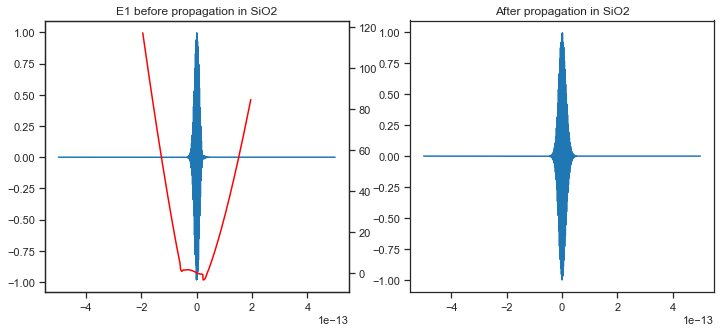

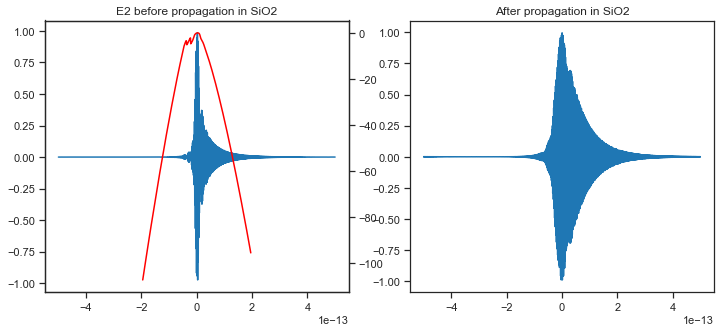

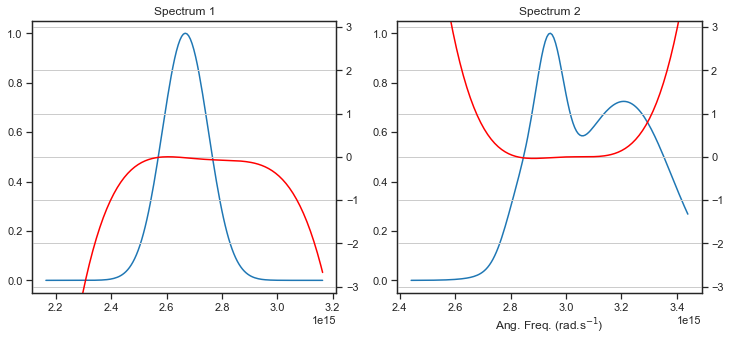

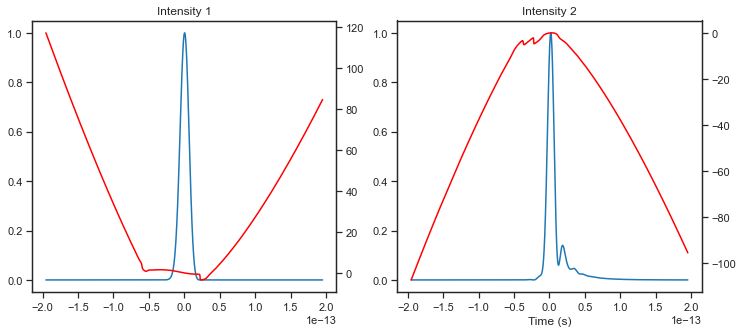

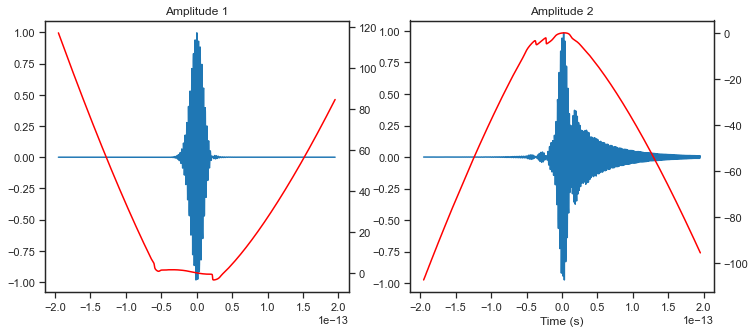

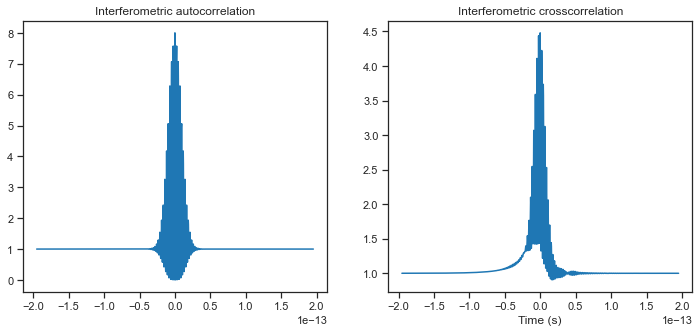

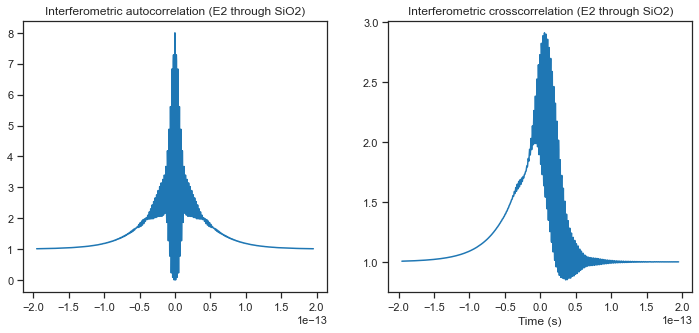

In [6]:
data_path = 'data/interf_autocorr_crosscorr_123_0_phase_at_centr_freq_plus_sio2_2mm_unconstrained_polyphase_20000samples-4/'

# save data only within boundaies defined by these parameters
di = 800
i1 = 2048 - di
i2 = 2048 + di

df = 400

dii = 1250
ii1 = 2048 - dii
ii2 = 2048 + dii




N_data_samples = 20000

for i in range(N_data_samples):#(N_data_samples):
    
    progressBar(i,N_data_samples)

    Nbt=4096
    
    lambda0_1, lambda0_2 = None,None#680*1e-9, 750*1e-9
    fwhm_lambda_1,fwhm_lambda_2=None,None#70,50
    n_peaks_1,n_peaks_2=None,None#6,12
    c1_1,c1_2=None,None#30,60
    c2_1,c2_2=None,None#1500,800
    c3_1,c3_2=None,None#0,0#5000,7500
    rand_shape=None#False
    sigma_sm = 5
    
    phase_E1 = 'poly'
    phase_E2 = 'poly'
    
    E1_t,E1_w,t,w,phi1_t,phi1_w,lambda0_1,fwhm_lambda_1,w0_1,fwhm_w_1,n_peaks_1,central_lambdas_1,central_w0s_1,fwhm_lambdas_1,fwhm_ws_1,amplitudes_1,phi2_1,phi3_1,phi4_1 = generate_pulse(Nbt=Nbt,lambda0=lambda0_1,fwhm_lambda=fwhm_lambda_1,n_peaks=n_peaks_1,c1=c1_1,c2=c2_1,c3=c3_1,rand_shape=rand_shape,sigma_sm=sigma_sm,phase=phase_E1)
    E2_t,E2_w,_,_,phi2_t,phi2_w,lambda0_2,fwhm_lambda_2,w0_2,fwhm_w_2,n_peaks_2,central_lambdas_2,central_w0s_2,fwhm_lambdas_2,fwhm_ws_2,amplitudes_2,phi2_2,phi3_2,phi4_2 = generate_pulse(Nbt=Nbt,lambda0=lambda0_2,fwhm_lambda=fwhm_lambda_2,n_peaks=n_peaks_2,c1=c1_2,c2=c2_2,c3=c3_2,rand_shape=rand_shape,sigma_sm=sigma_sm,phase=phase_E2)
    
    interferometric_autocorrelation_1 = interferometric_autocorr(E1_t,E1_t,t,1)
    interferometric_crosscorrelation_1 = interferometric_autocorr(E1_t,E2_t,t,1)
    
    interferometric_autocorrelation_2 = interferometric_autocorr(E1_t,E1_t,t,2)
    interferometric_autocorrelation_3 = interferometric_autocorr(E1_t,E1_t,t,3)
    interferometric_crosscorrelation_2 = interferometric_autocorr(E1_t,E2_t,t,2)
    interferometric_crosscorrelation_3 = interferometric_autocorr(E1_t,E2_t,t,3)
    
    ### inserting a 2 mm SiO2 plate
    
    # Length of the medium (in meters)
    L=2e-3

    #Setting the limit for plotting
    tmin=-5e-13
    tmax=5e-13

    medium='SiO2'#'air'#'bk7'#'SiO2'#'sf10'
    NbPoints=2

    _,_,E1_t_z_sio2,phi1_t_z_sio2=propagation(t,w,w0_1,E1_w,L,NbPoints,tmin,tmax,medium,plot1D=False,plot2D=False)
    _,_,E2_t_z_sio2,phi2_t_z_sio2=propagation(t,w,w0_2,E2_w,L,NbPoints,tmin,tmax,medium,plot1D=False,plot2D=False)

    E1_t_sio2 = E1_t_z_sio2[:,-1] # corresponds to the last point i.e. the output of the medium
    E2_t_sio2 = E2_t_z_sio2[:,-1]
    phi1_t_sio2 = phi1_t_z_sio2[:,-1]
    phi2_t_sio2 = phi2_t_z_sio2[:,-1]
    
    interferometric_autocorrelation_1_sio2_1 = interferometric_autocorr(E1_t_sio2,E1_t_sio2,t,1)
    interferometric_autocorrelation_1_sio2_2 = interferometric_autocorr(E2_t_sio2,E2_t_sio2,t,1)
    interferometric_crosscorrelation_1_sio2_1 = interferometric_autocorr(E1_t_sio2,E2_t,t,1)
    interferometric_crosscorrelation_1_sio2_2 = interferometric_autocorr(E1_t,E2_t_sio2,t,1)
    interferometric_crosscorrelation_1_sio2_12 = interferometric_autocorr(E1_t_sio2,E2_t_sio2,t,1)
    
    interferometric_autocorrelation_2_sio2_1 = interferometric_autocorr(E1_t_sio2,E1_t_sio2,t,2)
    interferometric_autocorrelation_2_sio2_2 = interferometric_autocorr(E2_t_sio2,E2_t_sio2,t,2)
    interferometric_crosscorrelation_2_sio2_1 = interferometric_autocorr(E1_t_sio2,E2_t,t,2)
    interferometric_crosscorrelation_2_sio2_2 = interferometric_autocorr(E1_t,E2_t_sio2,t,2)
    interferometric_crosscorrelation_2_sio2_12 = interferometric_autocorr(E1_t_sio2,E2_t_sio2,t,2)
    
    interferometric_autocorrelation_3_sio2_1 = interferometric_autocorr(E1_t_sio2,E1_t_sio2,t,3)
    interferometric_autocorrelation_3_sio2_2 = interferometric_autocorr(E2_t_sio2,E2_t_sio2,t,3)
    interferometric_crosscorrelation_3_sio2_1 = interferometric_autocorr(E1_t_sio2,E2_t,t,3)
    interferometric_crosscorrelation_3_sio2_2 = interferometric_autocorr(E1_t,E2_t_sio2,t,3)
    interferometric_crosscorrelation_3_sio2_12 = interferometric_autocorr(E1_t_sio2,E2_t_sio2,t,3)

#     #Plot of the duration along z
#     figure()
#     plot(Z,FWHM*1e15)
# #     title('Duration for {:.0f} fs - Propagation in {:.0f} m of {}'.format(duration_300fs*1e15,L,medium))
#     xlabel('Distance $z$ (m)')
#     ylabel('Duration (fs)')
# #     ylim((290,310))
#     show()
    
    ###############################
    
    other_parameters = np.array([lambda0_1,fwhm_lambda_1,w0_1,fwhm_w_1,n_peaks_1,*central_lambdas_1,*central_w0s_1,*fwhm_lambdas_1,*fwhm_ws_1,*amplitudes_1,phi2_1,phi3_1,phi4_1,lambda0_2,fwhm_lambda_2,w0_2,fwhm_w_2,n_peaks_2,*central_lambdas_2,*central_w0s_2,*fwhm_lambdas_2,*fwhm_ws_2,*amplitudes_2,phi2_2,phi3_2,phi4_2])
    
    # saving data
    sample_path = os.path.join(data_path,str(i))
    if not os.path.exists(sample_path):
        os.mkdir(sample_path)
    
    freqs_ = w[ii1+df:ii2+df]
    times_ = t[i1:i2]
    spectra_1_ = abs(E1_w[ii1+df:ii2+df])**2
    spectral_phases_1_ = phi1_w[ii1+df:ii2+df]
    ind_peak_1 = find_nearest(freqs_,w0_1)
#     print(ind_peak_1,np.argmax(spectra_1_))
#     print(ind_peak_1)
#     print(spectra_1_[ind_peak_1])
#     print(spectral_phases_1_[ind_peak_1])
    spectral_phases_1_ = spectral_phases_1_ - spectral_phases_1_[ind_peak_1]
    intensities_1_ = abs(E1_t[i1:i2])**2
    amplitudes_1_ = np.real(E1_t[i1:i2])
    temporal_phases_1_ = phi1_t[i1:i2]
    spectra_2_ = abs(E2_w[ii1+df:ii2+df])**2
    spectral_phases_2_ = phi2_w[ii1+df:ii2+df]
    ind_peak_2 = find_nearest(freqs_,w0_2)
#     print(ind_peak_2,np.argmax(spectra_2_))
    spectral_phases_2_ = spectral_phases_2_ - spectral_phases_2_[ind_peak_2]
    intensities_2_ = abs(E2_t[i1:i2])**2
    amplitudes_2_ = np.real(E2_t[i1:i2])
    temporal_phases_2_ = phi2_t[i1:i2]
    interf_autocorrelations_1_ = interferometric_autocorrelation_1[i1:i2]
    interf_autocorrelations_2_ = interferometric_autocorrelation_2[i1:i2]
    interf_autocorrelations_3_ = interferometric_autocorrelation_3[i1:i2]
    interf_crosscorrelations_1_ = interferometric_crosscorrelation_1[i1:i2]
    interf_crosscorrelations_2_ = interferometric_crosscorrelation_2[i1:i2]
    interf_crosscorrelations_3_ = interferometric_crosscorrelation_3[i1:i2]
    # stretched pulses in sio2
    temporal_phases_1_sio2_ = phi1_t_sio2[i1:i2]
    temporal_phases_2_sio2_ = phi2_t_sio2[i1:i2]
    intensities_1_sio2_ = abs(E1_t_sio2[i1:i2])**2
    amplitudes_1_sio2_ = np.real(E1_t_sio2[i1:i2])
    intensities_2_sio2_ = abs(E2_t_sio2[i1:i2])**2
    amplitudes_2_sio2_ = np.real(E2_t_sio2[i1:i2])
    interf_autocorrelations_1_sio2_1_ = interferometric_autocorrelation_1_sio2_1[i1:i2]
    interf_autocorrelations_1_sio2_2_ = interferometric_autocorrelation_1_sio2_2[i1:i2]
    interf_crosscorrelations_1_sio2_1_ = interferometric_crosscorrelation_1_sio2_1[i1:i2]
    interf_crosscorrelations_1_sio2_2_ = interferometric_crosscorrelation_1_sio2_2[i1:i2]
    interf_crosscorrelations_1_sio2_12_ = interferometric_crosscorrelation_1_sio2_12[i1:i2]  
    interf_autocorrelations_2_sio2_1_ = interferometric_autocorrelation_2_sio2_1[i1:i2]
    interf_autocorrelations_2_sio2_2_ = interferometric_autocorrelation_2_sio2_2[i1:i2]
    interf_crosscorrelations_2_sio2_1_ = interferometric_crosscorrelation_2_sio2_1[i1:i2]
    interf_crosscorrelations_2_sio2_2_ = interferometric_crosscorrelation_2_sio2_2[i1:i2]
    interf_crosscorrelations_2_sio2_12_ = interferometric_crosscorrelation_2_sio2_12[i1:i2]    
    interf_autocorrelations_3_sio2_1_ = interferometric_autocorrelation_3_sio2_1[i1:i2]
    interf_autocorrelations_3_sio2_2_ = interferometric_autocorrelation_3_sio2_2[i1:i2]
    interf_crosscorrelations_3_sio2_1_ = interferometric_crosscorrelation_3_sio2_1[i1:i2]
    interf_crosscorrelations_3_sio2_2_ = interferometric_crosscorrelation_3_sio2_2[i1:i2]
    interf_crosscorrelations_3_sio2_12_ = interferometric_crosscorrelation_3_sio2_12[i1:i2]
    # stacking
    time_domain_data_ = np.vstack((times_, intensities_1_, amplitudes_1_, temporal_phases_1_, intensities_2_, amplitudes_2_, temporal_phases_2_, interf_autocorrelations_1_, interf_autocorrelations_2_, interf_autocorrelations_3_, interf_crosscorrelations_1_, interf_crosscorrelations_2_, interf_crosscorrelations_3_)).T
    freq_domain_data_ = np.vstack((freqs_, spectra_1_, spectral_phases_1_, spectra_2_, spectral_phases_2_)).T
    time_domain_data_sio2_ = np.vstack((intensities_1_sio2_, amplitudes_1_sio2_, intensities_2_sio2_, amplitudes_2_sio2_,interf_autocorrelations_1_sio2_1_,interf_autocorrelations_1_sio2_2_,interf_crosscorrelations_1_sio2_1_,interf_crosscorrelations_1_sio2_2_,interf_crosscorrelations_1_sio2_12_,interf_autocorrelations_2_sio2_1_,interf_autocorrelations_2_sio2_2_,interf_crosscorrelations_2_sio2_1_,interf_crosscorrelations_2_sio2_2_,interf_crosscorrelations_2_sio2_12_,interf_autocorrelations_3_sio2_1_,interf_autocorrelations_3_sio2_2_,interf_crosscorrelations_3_sio2_1_,interf_crosscorrelations_3_sio2_2_,interf_crosscorrelations_3_sio2_12_)).T
    np.savetxt(os.path.join(sample_path,'time_domain_data_IAs.txt'), time_domain_data_.astype(np.float), fmt='%.8e',header="times_, intensities_1_, amplitudes_1_, temporal_phases_1_, intensities_2_, amplitudes_2_, temporal_phases_2_,interf_autocorrelations_1st_order, interf_autocorrelations_2nd_order, interf_autocorrelations_3rd_order, interf_crosscorrelations_1st_order, interf_crosscorrelations_2nd_order, interf_crosscorrelations_3rd_order") 
    np.savetxt(os.path.join(sample_path,'time_domain_data_IAs_sio2.txt'), time_domain_data_sio2_.astype(np.float), fmt='%.8e',header="intensities_1_sio2_, amplitudes_1_sio2_, intensities_2_sio2_, amplitudes_2_sio2_,interf_autocorrelations_1_sio2_1_,interf_autocorrelations_1_sio2_2_,interf_crosscorrelations_1_sio2_1_,interf_crosscorrelations_1_sio2_2_,interf_crosscorrelations_1_sio2_12_,interf_autocorrelations_2_sio2_1_,interf_autocorrelations_2_sio2_2_,interf_crosscorrelations_2_sio2_1_,interf_crosscorrelations_2_sio2_2_,interf_crosscorrelations_2_sio2_12_,interf_autocorrelations_3_sio2_1_,interf_autocorrelations_3_sio2_2_,interf_crosscorrelations_3_sio2_1_,interf_crosscorrelations_3_sio2_2_,interf_crosscorrelations_3_sio2_12_") 
    np.savetxt(os.path.join(sample_path,'freq_domain_data_IAs.txt'), freq_domain_data_.astype(np.float), fmt='%.8e',header="freqs_, spectra_1_, spectral_phases_1_, spectra_2_, spectral_phases_2_")
    np.savetxt(os.path.join(sample_path,'other_params_IAs.txt'), other_parameters.astype(np.float), fmt='%.8e',header="[lambda0_1,fwhm_lambda_1,w0_1,fwhm_w_1,n_peaks_1,*central_lambdas_1,*central_w0s_1,*fwhm_lambdas_1,*fwhm_ws_1,*amplitudes_1,phi2_1,phi3_1,phi4_1,lambda0_2,fwhm_lambda_2,w0_2,fwhm_w_2,n_peaks_2,*central_lambdas_2,*central_w0s_2,*fwhm_lambdas_2,*fwhm_ws_2,*amplitudes_2,phi2_2,phi3_2,phi4_2]")


%matplotlib inline
#Control size of figures
rcParams['figure.figsize'] = [12, 5]

maxind1 = np.argmax(spectra_1_)
maxind2 = np.argmax(spectra_2_)
vic = 80

fig, (ax,ax_) = subplots(1,2)
ax.plot(t,np.real(E1_t))
# ax.set_xlim([-100e-15,100e-15])
ax.set_title('E1 before propagation in SiO2')
ax11=ax.twinx()
ax11.plot(times_,temporal_phases_1_,'r-',label='Temp. phase 1')
ax_.plot(t,np.real(E1_t_sio2))
# ax_.set_xlim([-100e-15,100e-15])
ax_.set_title('After propagation in SiO2')

fig, (ax,ax_) = subplots(1,2)
ax.plot(t,np.real(E2_t))
# ax.set_xlim([-100e-15,100e-15])
ax.set_title('E2 before propagation in SiO2')
ax11=ax.twinx()
ax11.plot(times_,temporal_phases_2_,'r-',label='Temp. phase 2')
ax_.plot(t,np.real(E2_t_sio2))
# ax_.set_xlim([-100e-15,100e-15])
ax_.set_title('After propagation in SiO2')

fig, (ax,ax_) = subplots(1,2)
ax.plot(freqs_[maxind1-vic:maxind1+vic],spectra_1_[maxind1-vic:maxind1+vic],label='Spectrum 1')
ax.set_title('Spectrum 1')
xlabel('Ang. Freq. (rad.s$^{-1}$)')
# xlim((1.8e15,2.9e15))
ax11=ax.twinx()
ax11.plot(freqs_[maxind1-vic:maxind1+vic],spectral_phases_1_[maxind1-vic:maxind1+vic],'r-',label='Ang. phase 1')
ax11.set_ylim([-3.14,3.14])
ax11.grid(1)

ax_.plot(freqs_[maxind2-vic:maxind2+vic],spectra_2_[maxind2-vic:maxind2+vic],label='Spectrum 2')
ax_.set_title('Spectrum 2')
xlabel('Ang. Freq. (rad.s$^{-1}$)')
# xlim((1.8e15,2.9e15))
ax11=ax_.twinx()
ax11.plot(freqs_[maxind2-vic:maxind2+vic],spectral_phases_2_[maxind2-vic:maxind2+vic],'r-',label='Ang. phase 2')
ax11.set_ylim([-3.14,3.14])
ax11.grid(1)

fig, (ax,ax_) = subplots(1,2)
ax.plot(times_,intensities_1_,label='Intensity 1')
ax.set_title('Intensity 1')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))
ax22=ax.twinx()
ax22.plot(times_,temporal_phases_1_,'r-',label='Temp. phase 1')
#ax22.plot(t,-w0*(t*len(w)/len(t)+(max(t)-min(t))/2.*len(t)/len(w)),'b') #if Nbt!=Nbw
#ax22.plot(t,-w0*(t+(max(t)-min(t))/2),'b--')

ax_.plot(times_,intensities_2_,label='Intensity 2')
ax_.set_title('Intensity 2')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))
ax22=ax_.twinx()
ax22.plot(times_,temporal_phases_2_,'r-',label='Temp. phase 2')
#ax22.plot(t,-w0*(t*len(w)/len(t)+(max(t)-min(t))/2.*len(t)/len(w)),'b') #if Nbt!=Nbw
#ax22.plot(t,-w0*(t+(max(t)-min(t))/2),'b--')

fig, (ax,ax_) = subplots(1,2)
ax.plot(times_,amplitudes_1_,label='Amplitude 1')
ax.set_title('Amplitude 1')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))
ax33=ax.twinx()
ax33.plot(times_,temporal_phases_1_,'r-',label='Temp. phase 1')

ax_.plot(times_,amplitudes_2_,label='Amplitude 2')
ax_.set_title('Amplitude 2')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))
ax33=ax_.twinx()
ax33.plot(times_,temporal_phases_2_,'r-',label='Temp. phase 2')

fig, (ax,ax_) = subplots(1,2)
ax.plot(times_,interf_autocorrelations_2_,label='IA2')
ax.set_title('Interferometric autocorrelation')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))

# fig, ax = subplots(1,1)
# ax.plot(times_,interf_autocorrelations_3_,label='IA3')
# title('Interferometric autocorrelation')
# xlabel('Time (s)')
# # xlim((t[i1],t[i2]))

ax_.plot(times_,interf_crosscorrelations_2_,label='IC2')
ax_.set_title('Interferometric crosscorrelation')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))

# fig, ax = subplots(1,1)
# ax.plot(times_,interf_crosscorrelations_3_,label='IC3')
# title('Interferometric crosscorrelation')
# xlabel('Time (s)')
# # xlim((t[i1],t[i2]))

fig, (ax,ax_) = subplots(1,2)
ax.plot(times_,interf_autocorrelations_2_sio2_2_,label='IA2')
ax.set_title('Interferometric autocorrelation (E2 through SiO2)')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))
ax_.plot(times_,interf_crosscorrelations_2_sio2_2_,label='IC2')
ax_.set_title('Interferometric crosscorrelation (E2 through SiO2)')
xlabel('Time (s)')
# xlim((t[i1],t[i2]))


show()

# tt = signal.resample(t, 2000)
# f = signal.resample(interferometric_autocorrelation, 2000)
# print(np.shape(f))
# print(np.shape(interferometric_autocorrelation))
# figure()
# plot(tt,f,'b',markersize=12)
# plot(t,interferometric_autocorrelation)
# xlim((-5e-15,5e-15))

In [7]:
#plotting for paper


def importAutocorrTraces(root,image_depth,image_size,N_labels):
    dataset_path = os.path.join(root)
    folders = np.transpose(next(os.walk(dataset_path))[1])
    N = len(folders)
    images_ = np.empty((N,image_depth,image_size,image_size))
    labels__ = np.empty((N,3,N_labels))
    
    for i,folder in zip(range(N),folders):#zip(range(1),folders[0]):#for debugging
        current_path = os.path.join(dataset_path,folder)
        # inputs
        current_S_1 = np.genfromtxt(os.path.join(current_path,"freq_domain_data_IAs.txt"))[1250-800:1250+800,1] # spectra_1_
        current_S_2 = np.genfromtxt(os.path.join(current_path,"freq_domain_data_IAs.txt"))[1250-800:1250+800,3] # spectra_2_
        current_phiw_1 = np.genfromtxt(os.path.join(current_path,"freq_domain_data_IAs.txt"))[1250-800:1250+800,2] # spectra_1_
        current_phiw_2 = np.genfromtxt(os.path.join(current_path,"freq_domain_data_IAs.txt"))[1250-800:1250+800,4] # spectra_2_
        current_IA1_1 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[:,7] # interf_autocorrelations_1st_order
        current_IA2_1 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[:,8] # interf_autocorrelations_2nd_order
        current_IC1_12 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[:,10] # interf_crosscorrelations_1st_order
        current_IC2_12 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[:,11] # interf_crosscorrelations_2nd_order
        
        current_Et_2_sio2_2 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs_sio2.txt"))[800-500:800+500,3]
        current_IC1_sio2_2 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs_sio2.txt"))[:,7] # interf_crosscorrelations_1_sio2_2_
        current_IC2_sio2_2 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs_sio2.txt"))[:,12] # interf_crosscorrelations_2_sio2_2_
        
        # current_P = np.genfromtxt(os.path.join(current_path,"freq_domain_data_IAs.txt"))[1250-200:1250+200,4]
        current_Et_1 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[800-500:800+500,2] # amplitudes_2_
        current_Et_2 = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[800-500:800+500,5] # amplitudes_2_
        current_phit = np.genfromtxt(os.path.join(current_path,"time_domain_data_IAs.txt"))[800-450:800+450,6] # temporal_phases_2_
        current_field = [*current_Et_2,*current_phit]        
        
        # current_S_1 = np.reshape([*np.zeros(192),*current_S_1,*np.zeros(192)],(1,40,40))
        # current_S_2 = np.reshape([*np.zeros(192),*current_S_2,*np.zeros(192)],(1,40,40))
        current_S_1 = np.reshape(current_S_1,(1,40,40))
        current_S_2 = np.reshape(current_S_2,(1,40,40))
        current_phiw_1 = np.reshape(current_phiw_1,(1,40,40))
        current_phiw_2 = np.reshape(current_phiw_2,(1,40,40))
        current_IA1_1 = np.reshape(current_IA1_1[:],(1,40,40))
        current_IA2_1 = np.reshape(current_IA2_1[:],(1,40,40))
        current_IC1_12 = np.reshape(current_IC1_12[:],(1,40,40)) 
        current_IC2_12 = np.reshape(current_IC2_12[:],(1,40,40))
        current_IC1_sio2_2 = np.reshape(current_IC1_sio2_2[:],(1,40,40)) 
        current_IC2_sio2_2 = np.reshape(current_IC2_sio2_2[:],(1,40,40))
        # current_Et = np.asarray(np.reshape(current_Et[:],(1,40,40)))
        
        # image_combined = np.concatenate((current_S_1, current_S_2, current_IA1_1, current_IA2_1, current_IC1_12, current_IC2_12, current_IC1_12_sio2, current_IC2_12_sio2))
        # image_combined = np.concatenate((current_IA1_1, current_IA2_1, current_IC1_12, current_IC2_12, current_IC1_12_sio2, current_IC2_12_sio2))
        # image_combined = np.concatenate((current_S_1, current_S_2, current_IA2_1, current_IC2_12, current_IC2_sio2_2))
        image_combined = np.concatenate((current_S_1, current_phiw_1, current_S_2, current_phiw_2, current_IC2_12, current_IC2_sio2_2))
        # labels
        
        # print("np.shape(current_P)",np.shape(current_P))
        images_[i] = np.asarray(image_combined)
        # images_[i] = np.asarray(np.reshape(current_Et,(1,30,30)))
        
        
        # labels__[i] = current_P
        labels__[i] = [current_Et_1,current_Et_2,current_Et_2_sio2_2]#current_field
        # labels__[i] = current_phit#current_phase
    
    return images_,labels__

# define the data-folder
root_folder_autocorr = os.path.join(os.getcwd(),"data","interf_autocorr_crosscorr_123_0_phase_at_centr_freq_plus_sio2_2mm_unconstrained_polyphase_20000samples")
Input_depth = 6
images_autocorr_2,labels_autocorr= importAutocorrTraces(root_folder_autocorr,Input_depth,40,1000)

print(np.shape(images_autocorr_2),np.shape(labels_autocorr))



KeyboardInterrupt: 

In [ ]:
%matplotlib inline

fontsize = 19
dpi = 140
figsize = [6, 3]
linewidth = 3

#Control size of figures
rcParams['figure.figsize'] = figsize
rcParams.update({'font.size': fontsize})
rcParams.update({'lines.linewidth' : linewidth})
rcParams['figure.dpi'] = dpi

# 16685, 455,11530, 2525, 19191, 779, 1057,8125, 9437
sample_number = 9437#58#np.random.randint(0,100)
print(sample_number)

sc = 833
sm = 120

fig, ax = subplots(1,dpi=dpi,figsize=figsize)
lns1 = ax.plot(2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm:sc+sm],images_autocorr_2[sample_number].reshape(6,-1)[0][sc-sm:sc+sm],label='Spectrum (ref)')
# ax.set_title('Spectrum 1')
ax.tick_params(axis='y', colors='#1f77b4',labelsize = fontsize)
ax.tick_params(axis='x',labelsize = fontsize)
ax.set_xticks([600,700,800,900])
ax.set_yticks([0,1])
xlabel('Wavelength, nm',fontsize=fontsize)
ylabel('Intensity, a.u.',color='#1f77b4',fontsize=fontsize)
xlim((2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc+sm-1],2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm]))
ax11=ax.twinx()
lns2 = ax11.plot(2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm:sc+sm],images_autocorr_2[sample_number].reshape(6,-1)[1][sc-sm:sc+sm],'-',color="#ff7f0e",label='Phase (ref)')
ax11.set_ylim([-3.5,3.5])
ax11.tick_params(axis='y', colors="#ff7f0e",labelsize = fontsize)
ax11.tick_params(axis='x',labelsize = fontsize)
#ylabel('Phase, rad',color="#ff7f0e")
#ax.legend(["Spectrum","Phase"])
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax11.legend(lns, labs, loc='best',fontsize=19)
#ax11.set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])  # Set label locations.
#ax11.set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"0",r"$\pi/2$",r"$\pi$"])  # Set label locations.
#ax11.set_yticklabels([r"",r"",r"",r"",r""])  # Set label locations.
ax11.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    right=False,      # ticks along the bottom edge are off
    labelright=False) # labels along the bottom edge are off
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position('top')

fig, ax = subplots(1,dpi=dpi,figsize=figsize)
lns1 = ax.plot(2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm:sc+sm],images_autocorr_2[sample_number].reshape(6,-1)[2][sc-sm:sc+sm],label='Spectrum (?)')
# ax.set_title('Spectrum 1')
ax.tick_params(axis='y', colors='#1f77b4',labelsize = fontsize)
ax.tick_params(axis='x',labelsize = fontsize)
ax.set_xticks([600,700,800,900])
xlabel('Wavelength, nm',fontsize=fontsize)
#ylabel('Intensity, a.u.',color="#1f77b4")
xlim((2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc+sm-1],2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm]))
ax11=ax.twinx()
lns2 = ax11.plot(2*1e9*np.pi*3e8/freqs_[1250-800:1250+800][sc-sm:sc+sm],images_autocorr_2[sample_number].reshape(6,-1)[3][sc-sm:sc+sm],'-',color="#ff7f0e",label='Phase (?)')
ax11.set_ylim([-3.5,3.5])
ax11.tick_params(axis='y', colors="#ff7f0e",labelsize = fontsize)
ax11.tick_params(axis='x',labelsize = fontsize)
ylabel('Phase, rad',color="#ff7f0e",fontsize=fontsize)
#ax.legend(["Spectrum","Phase"])
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax11.legend(lns, labs, loc=1,fontsize=fontsize)
ax11.set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])  # Set label locations.
ax11.set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"0",r"$\pi/2$",r"$\pi$"])  # Set label locations.
ax.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    labelleft=False) # labels along the bottom edge are off
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position('top')



fontsize = 20
dpi = 140
figsize = [12, 3]

rcParams['figure.figsize'] = figsize
rcParams['figure.dpi'] = dpi
rcParams.update({'font.size': fontsize})

tm = 400
tc = 800

figure(dpi=dpi,figsize=figsize)
plot(1e15*times_[tc-tm:tc+tm],images_autocorr_2[sample_number].reshape(6,-1)[4][tc-tm:tc+tm],color='#2ca02c')
xlim([1e15*times_[tc-tm],1e15*times_[tc+tm]])
xlabel('Delay, fs',fontsize=fontsize)
ylabel('Intensity, a.u.',fontsize=fontsize)
legend(["IXC (without glass)"],loc=1,fontsize=fontsize)
yticks([2,4,6,8])
ylim([0,np.max(images_autocorr_2[sample_number].reshape(6,-1)[4][tc-tm:tc+tm])+0.5])
tick_params(axis='x',labelsize = fontsize)
tick_params(axis='y',labelsize = fontsize)


figure(dpi=dpi,figsize=figsize)
plot(1e15*times_[tc-tm:tc+tm],images_autocorr_2[sample_number].reshape(6,-1)[5][tc-tm:tc+tm],color='#2ca02c')
xlim([1e15*times_[tc-tm],1e15*times_[tc+tm]])
xlabel('Delay, fs',fontsize=fontsize)
ylabel('Intensity, a.u.',fontsize=fontsize)
legend(["IXC (with glass)"],loc=1,fontsize=fontsize)
yticks([2,4,6,8])
ylim([0,np.max(images_autocorr_2[sample_number].reshape(6,-1)[5][tc-tm:tc+tm])+0.5])
tick_params(axis='x',labelsize = fontsize)
tick_params(axis='y',labelsize = fontsize)


tm2 = 350
tc2 = 500

figure(dpi=dpi,figsize=figsize)
plot(1e15*times_[tc-tm:tc+tm],(labels_autocorr[sample_number].reshape(3,-1)[0][tc2-tm:tc2+tm]))
xlim([1e15*times_[tc-tm],1e15*times_[tc+tm]])
xlabel('Time, fs',fontsize=fontsize)
ylabel('Amplitude, a.u.',fontsize=fontsize)
legend([r"Electric field (ref)"],loc=1,fontsize=fontsize)
yticks([0,1])
tick_params(axis='x',labelsize = fontsize)
tick_params(axis='y',labelsize = fontsize)

figure(dpi=dpi,figsize=figsize)
plot(1e15*times_[tc-tm:tc+tm],(labels_autocorr[sample_number].reshape(3,-1)[1][tc2-tm:tc2+tm]))
xlim([1e15*times_[tc-tm],1e15*times_[tc+tm]])
xlabel('Time, fs',fontsize=fontsize)
ylabel('Amplitude, a.u.',fontsize=fontsize)
legend([r"Electric field (?)"],loc=1,fontsize=fontsize)
yticks([0,1])
tick_params(axis='x',labelsize = fontsize)
tick_params(axis='y',labelsize = fontsize)

figure(dpi=dpi,figsize=figsize)
plot(1e15*times_[tc-tm:tc+tm],(labels_autocorr[sample_number].reshape(3,-1)[2][tc2-tm:tc2+tm]))
xlim([1e15*times_[tc-tm],1e15*times_[tc+tm]])
xlabel('Time, fs',fontsize=fontsize)
ylabel('Amplitude, a.u.',fontsize=fontsize)
legend(["Electric field (?)\n(with glass)"],loc=1,fontsize=19)
yticks([0,1])
tick_params(axis='x',labelsize = fontsize)
tick_params(axis='y',labelsize = fontsize)


In [ ]:
# reshaped data (plots)

rcParams['figure.figsize'] = [12, 12]
rcParams['figure.dpi'] = 140
rcParams.update({'font.size': 26})

fig, ax = subplots(2,2,gridspec_kw = {'wspace':-0.04, 'hspace':0.013})

grid = images_autocorr_2[sample_number].reshape(6,40,40)[0].T #2,4,5
ax[0,0].imshow(grid,interpolation='none', cmap=modified_jet)
ax[0,0].tick_params(axis='both', which='both', length=0, labelsize=0)

grid = images_autocorr_2[sample_number].reshape(6,40,40)[2].T #2,4,5
ax[1,0].imshow(grid,interpolation='none', cmap=modified_jet)
ax[1,0].tick_params(axis='both', which='both', length=0, labelsize=0)

grid = images_autocorr_2[sample_number].reshape(6,40,40)[4].T #2,4,5
ax[0,1].imshow(grid,interpolation='none', cmap=modified_jet)
ax[0,1].tick_params(axis='both', which='both', length=0, labelsize=0)

grid = images_autocorr_2[sample_number].reshape(6,40,40)[5].T #2,4,5
neg = ax[1,1].imshow(grid,interpolation='none', cmap=modified_jet)
ax[1,1].tick_params(axis='both', which='both', length=0, labelsize=0)

ax[0,0].text(1.6, 4, "Spectrum (ref)", bbox={'edgecolor': 'red','facecolor': 'white', 'pad': 10, "alpha": 0.85})
ax[0,1].text(1.6, 4, "IXC (without glass)", bbox={'edgecolor': 'red','facecolor': 'white', 'pad': 10, "alpha": 0.85})
ax[1,0].text(1.6, 4, "Spectrum (?)", bbox={'edgecolor': 'red','facecolor': 'white', 'pad': 10, "alpha": 0.85})
ax[1,1].text(1.6, 4, "IXC (with glass)", bbox={'edgecolor': 'red','facecolor': 'white', 'pad': 10, "alpha": 0.85})

# tight_layout()
# fig.subplots_adjust(left=0.1,bottom=0.1)

clbr_text_size = 50

fig, ax = subplots(1,1,gridspec_kw = {'wspace':0, 'hspace':0})
grid = images_autocorr_2[sample_number].reshape(6,40,40)[0].T #2,4,5
neg = ax.imshow(grid,interpolation='none', cmap=modified_jet)
ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_aspect("equal")
cbar = fig.colorbar(neg, ax=ax, use_gridspec=False, location='right',shrink = 0.82)
cbar.ax.tick_params(labelsize=clbr_text_size)
cbar.set_label(label = "Intensity, a.u.",fontsize=clbr_text_size)
cbar.set_ticks([0,1,2,3,4,5,6,7,8])

fig, ax = subplots(1,1,gridspec_kw = {'wspace':0, 'hspace':0})
grid = images_autocorr_2[sample_number].reshape(6,40,40)[2].T #2,4,5
neg = ax.imshow(grid,interpolation='none', cmap=modified_jet)
ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_aspect("equal")
cbar = fig.colorbar(neg, ax=ax, use_gridspec=False, location='right',shrink = 0.82)
cbar.ax.tick_params(labelsize=clbr_text_size)
cbar.set_label(label = "Intensity, a.u.",fontsize=clbr_text_size)
cbar.set_ticks([0,1,2,3,4,5,6,7,8])

fig, ax = subplots(1,1,gridspec_kw = {'wspace':0, 'hspace':0})
grid = images_autocorr_2[sample_number].reshape(6,40,40)[4].T #2,4,5
neg = ax.imshow(grid,interpolation='none', cmap=modified_jet)
ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_aspect("equal")
cbar = fig.colorbar(neg, ax=ax, use_gridspec=False, location='right',shrink = 0.82)
cbar.ax.tick_params(labelsize=clbr_text_size)
cbar.set_label(label = "Intensity, a.u.",fontsize=clbr_text_size)
cbar.set_ticks([0,1,2,3,4,5,6,7,8])

fig, ax = subplots(1,1,gridspec_kw = {'wspace':0, 'hspace':0})
grid = images_autocorr_2[sample_number].reshape(6,40,40)[5].T #2,4,5
neg = ax.imshow(grid,interpolation='none', cmap=modified_jet)
ax.tick_params(axis='both', which='both', length=0, labelsize=0)
ax.set_aspect("equal")
cbar = fig.colorbar(neg, ax=ax, use_gridspec=False, location='right',shrink = 0.82)
cbar.ax.tick_params(labelsize=clbr_text_size)
cbar.set_label(label = "Intensity, a.u.",fontsize=clbr_text_size)
cbar.set_ticks([0,1,2,3,4,5,6,7,8])


rcParams['figure.figsize'] = [4, 4]
figure()
plot((labels_autocorr[sample_number].reshape(3,-1)[1][tc2-tm:tc2+tm]), linewidth=2)
yticks([])
xticks([])
xlim([220,650])

In [387]:
# adding noise to the data

data_path = os.path.join(os.getcwd(),"data","interf_autocorr_crosscorr_123_0_phase_at_centr_freq_plus_sio2_2mm_unconstrained_polyphase_20000samples")


for sample_number in range(20000):# 16685
    
    progressBar(sample_number,20000)

    S1 = images_autocorr_2[sample_number].reshape(6,40,40)[0].reshape(-1)
    S2 = images_autocorr_2[sample_number].reshape(6,40,40)[2].reshape(-1)
    IXC1 = images_autocorr_2[sample_number].reshape(6,40,40)[4].reshape(-1)
    IXC2 = images_autocorr_2[sample_number].reshape(6,40,40)[5].reshape(-1)
    label_ = labels_autocorr[sample_number].reshape(3,-1)[1]


    # Set a target SNR and mean
    snr2 = 1.4
    snr2 = 2
    snr5 = 5
    snr10 = 10
    snr20 = 20
    mean_noise = 0

    # generating noise for spectra
    S1_max = np.max(S1)
    S2_max = np.max(S2)
    

    # generating noise for IXC
    # this is to later define noise relative to the fringe contrast
    x = np.linspace(0,len(IXC1),len(IXC1))
    delta = 10 # the width of the smoothed region of the filter function in pixels
    a = 50 # the width of the fitler function in pixels
    window = -1/2*(np.tanh((x-len(IXC1)//2-a)/delta)-np.tanh((x-len(IXC1)//2+a)/delta))
    # subtracting 0-frequency component from IXC
    BG1 = np.real(ifft(fftshift(window*fftshift((fft(IXC1))))))
    BG2 = np.real(ifft(fftshift(window*fftshift((fft(IXC2))))))
    IXC1_noBG = IXC1 - BG1
    IXC2_noBG = IXC2 - BG2
    # calculating the fringe contrast
    fringe_contrast_IXC1 = (np.max(IXC1_noBG) - np.min(IXC1_noBG))*2
    fringe_contrast_IXC2 = (np.max(IXC2_noBG) - np.min(IXC2_noBG))*2
    
    IXC1_max = np.max(BG1-1)
    IXC2_max = np.max(BG2-1)

    # defining noises
    noise_S1_1 = np.random.normal(mean_noise, (S1_max/snr1)**2, len(S1))
    noise_S2_1 = np.random.normal(mean_noise, (S2_max/snr1)**2, len(S2))
    noise_IXC1_1 = np.random.normal(mean_noise, ((IXC1_max)/snr1)**2, len(IXC1))
    noise_IXC2_1 = np.random.normal(mean_noise, ((IXC2_max)/snr1)**2, len(IXC2))
#     noise_IXC1_1 = np.random.normal(mean_noise, (fringe_contrast_IXC1/snr1)**2, len(IXC1))
#     noise_IXC2_1 = np.random.normal(mean_noise, (fringe_contrast_IXC2/snr1)**2, len(IXC2))

    noise_S1_2 = np.random.normal(mean_noise, (S1_max/snr2)**2, len(S1))
    noise_S2_2 = np.random.normal(mean_noise, (S2_max/snr2)**2, len(S2))
    noise_IXC1_2 = np.random.normal(mean_noise, ((IXC1_max)/snr2)**2, len(IXC1))
    noise_IXC2_2 = np.random.normal(mean_noise, ((IXC2_max)/snr2)**2, len(IXC2))
#     noise_IXC1_2 = np.random.normal(mean_noise, (fringe_contrast_IXC1/snr2)**2, len(IXC1))
#     noise_IXC2_2 = np.random.normal(mean_noise, (fringe_contrast_IXC2/snr2)**2, len(IXC2))

    noise_S1_5 = np.random.normal(mean_noise, (S1_max/snr5)**2, len(S1))
    noise_S2_5 = np.random.normal(mean_noise, (S2_max/snr5)**2, len(S2))
    noise_IXC1_5 = np.random.normal(mean_noise, ((IXC1_max)/snr5)**2, len(IXC1))
    noise_IXC2_5 = np.random.normal(mean_noise, ((IXC2_max)/snr5)**2, len(IXC2))
#     noise_IXC1_5 = np.random.normal(mean_noise, (fringe_contrast_IXC1/snr5)**2, len(IXC1))
#     noise_IXC2_5 = np.random.normal(mean_noise, (fringe_contrast_IXC2/snr5)**2, len(IXC2))

    noise_S1_10 = np.random.normal(mean_noise, (S1_max/snr10)**2, len(S1))
    noise_S2_10 = np.random.normal(mean_noise, (S2_max/snr10)**2, len(S2))
    noise_IXC1_10 = np.random.normal(mean_noise, ((IXC1_max)/snr10)**2, len(IXC1))
    noise_IXC2_10 = np.random.normal(mean_noise, ((IXC2_max)/snr10)**2, len(IXC2))
#     noise_IXC1_10 = np.random.normal(mean_noise, (fringe_contrast_IXC1/snr10)**2, len(IXC1))
#     noise_IXC2_10 = np.random.normal(mean_noise, (fringe_contrast_IXC2/snr10)**2, len(IXC2))

    noise_S1_20 = np.random.normal(mean_noise, (S1_max/snr20)**2, len(S1))
    noise_S2_20 = np.random.normal(mean_noise, (S2_max/snr20)**2, len(S2))
    noise_IXC1_20 = np.random.normal(mean_noise, ((IXC1_max)/snr20)**2, len(IXC1))
    noise_IXC2_20 = np.random.normal(mean_noise, ((IXC2_max)/snr20)**2, len(IXC2))
#     noise_IXC1_20 = np.random.normal(mean_noise, (fringe_contrast_IXC1/snr20)**2, len(IXC1))
#     noise_IXC2_20 = np.random.normal(mean_noise, (fringe_contrast_IXC2/snr20)**2, len(IXC2))

    S1_noisy_1 = S1 + noise_S1_1
    S2_noisy_1 = S2 + noise_S2_1
    IXC1_noisy_1 = IXC1 + noise_IXC1_1
    IXC2_noisy_1 = IXC2 + noise_IXC2_1

    S1_noisy_2 = S1 + noise_S1_2
    S2_noisy_2 = S2 + noise_S2_2
    IXC1_noisy_2 = IXC1 + noise_IXC1_2
    IXC2_noisy_2 = IXC2 + noise_IXC2_2

    S1_noisy_5 = S1 + noise_S1_5
    S2_noisy_5 = S2 + noise_S2_5
    IXC1_noisy_5 = IXC1 + noise_IXC1_5
    IXC2_noisy_5 = IXC2 + noise_IXC2_5

    S1_noisy_10 = S1 + noise_S1_10
    S2_noisy_10 = S2 + noise_S2_10
    IXC1_noisy_10 = IXC1 + noise_IXC1_10
    IXC2_noisy_10 = IXC2 + noise_IXC2_10

    S1_noisy_20 = S1 + noise_S1_20
    S2_noisy_20 = S2 + noise_S2_20
    IXC1_noisy_20 = IXC1 + noise_IXC1_20
    IXC2_noisy_20 = IXC2 + noise_IXC2_20






    noisy_input_data_ = np.vstack((S1,S2,IXC1,IXC2,S1_noisy_1,S2_noisy_1,IXC1_noisy_1,IXC2_noisy_1,\
                                  S1_noisy_2,S2_noisy_2,IXC1_noisy_2,IXC2_noisy_2,\
                                  S1_noisy_5,S2_noisy_5,IXC1_noisy_5,IXC2_noisy_5,\
                                  S1_noisy_10,S2_noisy_10,IXC1_noisy_10,IXC2_noisy_10,\
                                  S1_noisy_20,S2_noisy_20,IXC1_noisy_20,IXC2_noisy_20)).T
    
    label_for_noisy_ = np.vstack((label_))

    sample_path = os.path.join(data_path,str(sample_number))
    os.remove(os.path.join(sample_path,'noisy_input_data.txt'))
    np.savetxt(os.path.join(sample_path,'noisy_input_data.txt'), noisy_input_data_.astype(np.float), fmt='%.8e',header="S1,S2,IXC1,IXC2,S1_noisy_1,S2_noisy_1,IXC1_noisy_1,IXC2_noisy_1,S1_noisy_2,S2_noisy_2,IXC1_noisy_2,IXC2_noisy_2,S1_noisy_5,S2_noisy_5,IXC1_noisy_5,IXC2_noisy_5,S1_noisy_10,S2_noisy_10,IXC1_noisy_10,IXC2_noisy_10,S1_noisy_20,S2_noisy_20,IXC1_noisy_20,IXC2_noisy_20") 

    os.remove(os.path.join(sample_path,'label_for_noisy_data.txt'))
    np.savetxt(os.path.join(sample_path,'label_for_noisy_data.txt'), label_for_noisy_.astype(np.float), fmt='%.8e',header="label") 





In [ ]:
# import noisy data

def importAutocorrTracesNoisy(root,image_depth,image_size):
    dataset_path = os.path.join(root)
    folders = np.transpose(next(os.walk(dataset_path))[1])
    N = len(folders)
    images_0_ = np.empty((N,image_depth,image_size,image_size))
    images_1_ = np.empty((N,image_depth,image_size,image_size))
    images_2_ = np.empty((N,image_depth,image_size,image_size))
    images_3_ = np.empty((N,image_depth,image_size,image_size))
    images_4_ = np.empty((N,image_depth,image_size,image_size))
    images_5_ = np.empty((N,image_depth,image_size,image_size))
    for i,folder in zip(range(N),folders):#zip(range(1),folders[0]):#for debugging
        progressBar(i,N)
        current_path = os.path.join(dataset_path,folder)
        
        current_S_1 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,0] # spectra_1_
        current_S_2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,1] # spectra_2_
        current_IC2_12 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,2] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,3] # interf_crosscorrelations_2_sio2_2_
        current_S_1 = np.reshape(current_S_1,(1,40,40))
        current_S_2 = np.reshape(current_S_2,(1,40,40))
        current_IC2_12 = np.reshape(current_IC2_12[:],(1,40,40))
        current_IC2_sio2_2 = np.reshape(current_IC2_sio2_2[:],(1,40,40))
        
        current_S_1_noisy1 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,4] # spectra_1_
        current_S_2_noisy1 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,5] # spectra_2_
        current_IC2_12_noisy1 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,6] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2_noisy1 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,7] # interf_crosscorrelations_2_sio2_2_
        current_S_1_noisy1 = np.reshape(current_S_1_noisy1,(1,40,40))
        current_S_2_noisy1 = np.reshape(current_S_2_noisy1,(1,40,40))
        current_IC2_12_noisy1 = np.reshape(current_IC2_12_noisy1[:],(1,40,40))
        current_IC2_sio2_2_noisy1 = np.reshape(current_IC2_sio2_2_noisy1[:],(1,40,40))
        
        current_S_1_noisy2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,8] # spectra_1_
        current_S_2_noisy2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,9] # spectra_2_
        current_IC2_12_noisy2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,10] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2_noisy2 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,11] # interf_crosscorrelations_2_sio2_2_
        current_S_1_noisy2 = np.reshape(current_S_1_noisy2,(1,40,40))
        current_S_2_noisy2 = np.reshape(current_S_2_noisy2,(1,40,40))
        current_IC2_12_noisy2 = np.reshape(current_IC2_12_noisy2[:],(1,40,40))
        current_IC2_sio2_2_noisy2 = np.reshape(current_IC2_sio2_2_noisy2[:],(1,40,40))
        
        current_S_1_noisy5 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,12] # spectra_1_
        current_S_2_noisy5 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,13] # spectra_2_
        current_IC2_12_noisy5 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,14] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2_noisy5 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,15] # interf_crosscorrelations_2_sio2_2_
        current_S_1_noisy5 = np.reshape(current_S_1_noisy5,(1,40,40))
        current_S_2_noisy5 = np.reshape(current_S_2_noisy5,(1,40,40))
        current_IC2_12_noisy5 = np.reshape(current_IC2_12_noisy5[:],(1,40,40))
        current_IC2_sio2_2_noisy5 = np.reshape(current_IC2_sio2_2_noisy5[:],(1,40,40))
        
        current_S_1_noisy10 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,16] # spectra_1_
        current_S_2_noisy10 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,17] # spectra_2_
        current_IC2_12_noisy10 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,18] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2_noisy10 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,19] # interf_crosscorrelations_2_sio2_2_
        current_S_1_noisy10 = np.reshape(current_S_1_noisy10,(1,40,40))
        current_S_2_noisy10 = np.reshape(current_S_2_noisy10,(1,40,40))
        current_IC2_12_noisy10 = np.reshape(current_IC2_12_noisy10[:],(1,40,40))
        current_IC2_sio2_2_noisy10 = np.reshape(current_IC2_sio2_2_noisy10[:],(1,40,40))
        
        current_S_1_noisy20 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,20] # spectra_1_
        current_S_2_noisy20 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,21] # spectra_2_
        current_IC2_12_noisy20 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,22] # interf_crosscorrelations_2nd_order
        current_IC2_sio2_2_noisy20 = np.genfromtxt(os.path.join(current_path,"noisy_input_data.txt"))[:,23] # interf_crosscorrelations_2_sio2_2_
        current_S_1_noisy20 = np.reshape(current_S_1_noisy20,(1,40,40))
        current_S_2_noisy20 = np.reshape(current_S_2_noisy20,(1,40,40))
        current_IC2_12_noisy20 = np.reshape(current_IC2_12_noisy20[:],(1,40,40))
        current_IC2_sio2_2_noisy20 = np.reshape(current_IC2_sio2_2_noisy20[:],(1,40,40))
        
        image_combined_0 = np.concatenate((current_S_1, current_S_2, current_IC2_12, current_IC2_sio2_2))
        image_combined_1 = np.concatenate((current_S_1_noisy1, current_S_2_noisy1, current_IC2_12_noisy1, current_IC2_sio2_2_noisy1))
        image_combined_2 = np.concatenate((current_S_1_noisy2, current_S_2_noisy2, current_IC2_12_noisy2, current_IC2_sio2_2_noisy2))
        image_combined_3 = np.concatenate((current_S_1_noisy5, current_S_2_noisy5, current_IC2_12_noisy5, current_IC2_sio2_2_noisy5))
        image_combined_4 = np.concatenate((current_S_1_noisy10, current_S_2_noisy10, current_IC2_12_noisy10, current_IC2_sio2_2_noisy10))
        image_combined_5 = np.concatenate((current_S_1_noisy20, current_S_2_noisy20, current_IC2_12_noisy20, current_IC2_sio2_2_noisy20))
        images_0_[i] = np.asarray(image_combined_0)
        images_1_[i] = np.asarray(image_combined_1)
        images_2_[i] = np.asarray(image_combined_2)
        images_3_[i] = np.asarray(image_combined_3)
        images_4_[i] = np.asarray(image_combined_4)
        images_5_[i] = np.asarray(image_combined_5)
    return images_0_,images_1_,images_2_,images_3_,images_4_,images_5_

# define the data-folder
root_folder_autocorr = os.path.join(os.getcwd(),"data","interf_autocorr_crosscorr_123_0_phase_at_centr_freq_plus_sio2_2mm_unconstrained_polyphase_20000samples")
Input_depth = 4
images_autocorr_2_noisy0,\
    images_autocorr_2_noisy1,\
        images_autocorr_2_noisy2,\
            images_autocorr_2_noisy5,\
                images_autocorr_2_noisy10,\
                    images_autocorr_2_noisy20 = importAutocorrTracesNoisy(root_folder_autocorr,Input_depth,40)